# 2.11 — Who out-populars a superhero?

**Week 2 · Models & null models · Go nuts with your LLM 🚀 Builder · group**

[Official Week 2 assignment](https://sunelehmann.com/socialgraphs2026-web/weeks/week2.html)

## Research question

Does the friendship paradox hold in the Marvel network? Which characters are repeatedly sampled as the unusually popular friend, and is anyone connected to **no** character more popular than themselves?

We use the undirected network because friendship is treated as mutual for this question: either Wikipedia article linking to the other creates one relationship. Reciprocal links are collapsed, self-links would be removed, and the 17 isolates remain in global degree statistics but cannot enter a person–friend sample.

In [1]:
import json
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import sgi

sgi.set_style()
SEED = 20260914
G, nodes = sgi.load_marvel(week=1)
U = G.to_undirected()

assert len(G) == 303
assert G.number_of_edges() == 1784
assert U.number_of_edges() == 1434
assert nx.number_of_isolates(U) == 17
print(f"Loaded {len(U)} characters, {U.number_of_edges()} relationships, and {nx.number_of_isolates(U)} isolates.")

Loaded 303 characters, 1434 relationships, and 17 isolates.


## 1. Our sampling rule

We follow one experiment throughout: select a non-isolated **person uniformly**, then select one of that person's friends uniformly. Every eligible character has the same chance of being the person. We calculate the result exactly and use simulation only as an independent check.

In [2]:
summary = sgi.friendship_summary(U)

global_results = pd.DataFrame([
    {"quantity": "random non-isolated person", "mean degree": summary["person_mean_degree"]},
    {"quantity": "friend of a random non-isolate", "mean degree": summary["friend_mean_degree"]},
])
display(global_results.style.format({"mean degree": "{:.2f}"}))

,quantity,mean degree
0,random non-isolated person,10.03
1,friend of a random non-isolate,24.22


## 2. Does a sampled friend beat the sampled person?

The exact probabilities below average over every possible person–friend draw. We then simulate 20,000 draws as an independent implementation check. ‘At least as popular’ includes ties, matching the course wording; ‘more popular’ is strict.

In [3]:
pairs = sgi.sample_friendship_pairs(U, samples=20_000, seed=SEED, nodes=nodes)
comparison = pd.DataFrame({
    "measure": ["mean person degree", "mean friend degree", "P(friend > person)", "P(friend ≥ person)"],
    "exact": [
        summary["person_mean_degree"],
        summary["friend_mean_degree"],
        summary["friend_more_popular_probability"],
        summary["friend_at_least_as_popular_probability"],
    ],
    "20,000 simulated draws": [
        pairs["person_degree"].mean(),
        pairs["friend_degree"].mean(),
        pairs["friend_more_popular"].mean(),
        pairs["friend_at_least_as_popular"].mean(),
    ],
})
display(comparison.style.format({"exact": "{:.3f}", "20,000 simulated draws": "{:.3f}"}))
assert abs(pairs["friend_degree"].mean() - summary["friend_mean_degree"]) < 0.5

,measure,exact,"20,000 simulated draws"
0,mean person degree,10.028,10.032
1,mean friend degree,24.223,24.206
2,P(friend > person),0.714,0.715
3,P(friend ≥ person),0.753,0.751


## 3. The paradox as a local experience

For each non-isolated character we compare their own degree with the mean and maximum degree among their neighbors. The local paradox holds when the mean neighbor degree is higher. A character is **unbeaten** when no direct neighbor has strictly higher degree. This definition deliberately excludes isolates: having no neighbors is not winning a popularity contest.

In [4]:
friendship = sgi.friendship_table(U, nodes)
connected = friendship[friendship["degree"] > 0].copy()
unbeaten = connected[connected["unbeaten"]].sort_values("degree", ascending=False)
most_outpopularized = connected.nlargest(10, "neighbor_degree_gap")

print(
    f"The mean-neighbor paradox holds for {summary['local_paradox_count']} of "
    f"{summary['eligible_person_count']} non-isolated characters "
    f"({summary['local_paradox_fraction']:.1%})."
)
print(f"Only {len(unbeaten)} characters are unbeaten by a direct neighbor:")
display(unbeaten[["name", "degree", "mean_neighbor_degree", "max_neighbor_degree"]].style.format({
    "mean_neighbor_degree": "{:.2f}", "max_neighbor_degree": "{:.0f}"
}))
print("Largest gaps between a character's degree and their friends' mean degree:")
display(most_outpopularized[["name", "degree", "mean_neighbor_degree", "neighbor_degree_gap"]].style.format({
    "mean_neighbor_degree": "{:.2f}", "neighbor_degree_gap": "{:+.2f}"
}))

The mean-neighbor paradox holds for 250 of 286 non-isolated characters (87.4%).
Only 2 characters are unbeaten by a direct neighbor:


,name,degree,mean_neighbor_degree,max_neighbor_degree
246,Spider-Man,106,14.92,65
200,Radian (Morituri),6,2.67,3


Largest gaps between a character's degree and their friends' mean degree:


,name,degree,mean_neighbor_degree,neighbor_degree_gap
83,Enigma (Marvel Comics),1,106.00,+105.00
84,Ethan Edwards,1,106.00,+105.00
114,Helix (Marvel Comics),1,106.00,+105.00
178,Phil Grayfield,1,106.00,+105.00
272,Thunderclap (comics),1,106.00,+105.00
225,Scorpio (Marvel Comics),2,84.50,+82.50
236,Silhouette (comics),2,67.00,+65.00
47,Captain Ultra,1,57.00,+56.00
174,Moonglow (comics),1,57.00,+56.00
85,Fabio Medina,3,54.67,+51.67


## 4. Who keeps appearing as the popular friend?

A hub is available from many neighborhoods, but neighborhoods are not sampled equally. If $v$ is the candidate friend, its exact probability is

$$P(v\text{ is sampled}) = \frac{1}{n_+} \sum_{u \in N(v)} \frac{1}{k_u},$$

where $n_+$ is the number of non-isolates. Connecting to low-degree characters makes a hub even more likely to be picked, because those characters have fewer possible friends to choose from.

In [5]:
drivers = sgi.popular_friends(U, nodes, n=None)
assert np.isclose(drivers["friend_sample_probability"].sum(), 1)
top_drivers = drivers.head(12).copy()

driver_view = top_drivers[[
    "name", "degree", "friend_sample_probability",
    "overrepresentation", "lower_degree_neighbors",
]]
display(driver_view.style.format({
    "friend_sample_probability": "{:.2%}",
    "overrepresentation": "{:.1f}×",
}))
print(f"The top five account for {drivers.head(5)['friend_sample_probability'].sum():.1%} of all friend draws.")

,name,degree,friend_sample_probability,overrepresentation,lower_degree_neighbors
0,Spider-Man,106,5.65%,16.1×,106
1,Hulk,65,2.74%,7.8×,64
2,Wolverine (character),63,2.45%,7.0×,61
3,Doctor Strange,57,2.45%,7.0×,55
4,Deadpool,41,1.90%,5.4×,37
5,She-Hulk,37,1.59%,4.5×,32
6,Black Widow (Natasha Romanova),25,1.25%,3.6×,17
7,Hercules (Marvel Comics),26,1.22%,3.5×,22
8,Cyclops (Marvel Comics),26,1.18%,3.4×,20
9,Deathlok,20,1.15%,3.3×,13


The top five account for 15.2% of all friend draws.


## 5. Compared with what?

We compare the real network with 100 realizations of two nulls. A degree-preserving shuffle keeps every character's degree but destroys the specific pairing pattern. $G(n,m)$ keeps only the number of characters and relationships, removing the hubs. If degree heterogeneity drives the paradox, shuffling should preserve most of it while $G(n,m)$ should shrink it.

In [6]:
rng = np.random.default_rng(SEED)
null_records = []
for replicate in range(100):
    shuffled = U.copy()
    nx.double_edge_swap(
        shuffled,
        nswap=10 * U.number_of_edges(),
        max_tries=200 * U.number_of_edges(),
        seed=int(rng.integers(2**32 - 1)),
    )
    assert sorted(dict(shuffled.degree()).values()) == sorted(dict(U.degree()).values())
    null_records.append({"model": "degree-preserving shuffle", "replicate": replicate, **sgi.friendship_summary(shuffled)})

    random_graph = nx.gnm_random_graph(
        U.number_of_nodes(), U.number_of_edges(), seed=int(rng.integers(2**32 - 1))
    )
    null_records.append({"model": "G(n,m)", "replicate": replicate, **sgi.friendship_summary(random_graph)})

nulls = pd.DataFrame(null_records)
metrics = ["friend_mean_degree", "friend_at_least_as_popular_probability", "local_paradox_fraction", "unbeaten_count"]
null_summary = nulls.groupby("model")[metrics].agg(["mean", "std", "min", "max"])
display(null_summary.style.format("{:.3f}"))

## 6. One figure for the post

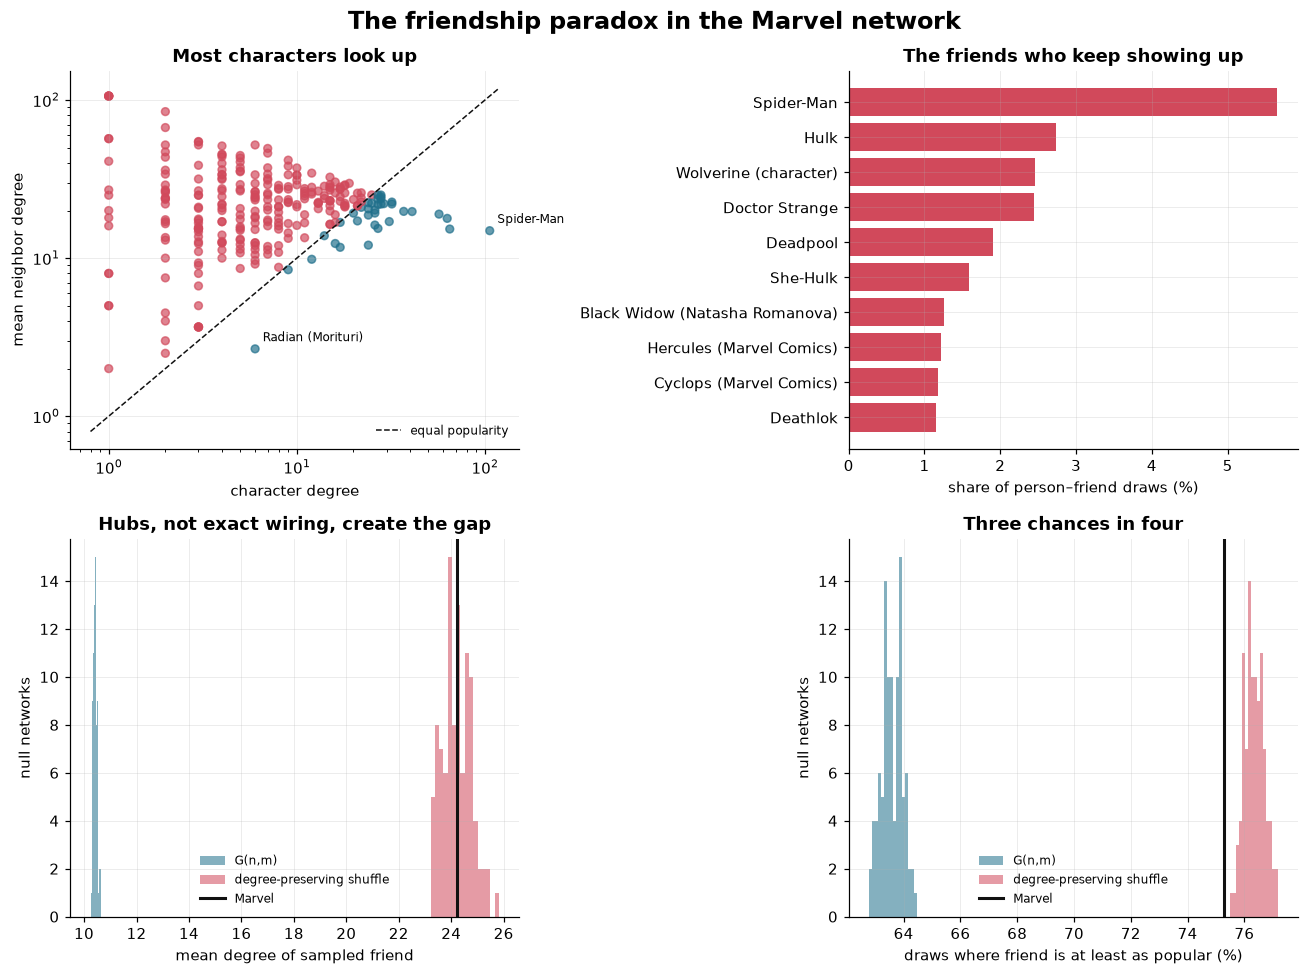

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
red, blue, ink = sgi.PALETTE["in"], sgi.PALETTE["out"], sgi.PALETTE["bin"]

ax = axes[0, 0]
colors = np.where(connected["local_paradox"], red, blue)
ax.scatter(connected["degree"], connected["mean_neighbor_degree"], c=colors, s=26, alpha=0.68)
limit = max(connected["degree"].max(), connected["mean_neighbor_degree"].max()) * 1.12
ax.plot([0.8, limit], [0.8, limit], color=ink, lw=1, ls="--", label="equal popularity")
for name in ["Spider-Man", "Radian (Morituri)"]:
    row = connected.loc[connected["name"] == name].iloc[0]
    ax.annotate(name, (row["degree"], row["mean_neighbor_degree"]), xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set(xscale="log", yscale="log", xlabel="character degree", ylabel="mean neighbor degree", title="Most characters look up")
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
bars = top_drivers.head(10).sort_values("friend_sample_probability")
ax.barh(bars["name"], 100 * bars["friend_sample_probability"], color=red)
ax.set(xlabel="share of person–friend draws (%)", title="The friends who keep showing up")

ax = axes[1, 0]
for model, color in [("G(n,m)", blue), ("degree-preserving shuffle", red)]:
    values = nulls.loc[nulls["model"] == model, "friend_mean_degree"]
    ax.hist(values, bins=16, alpha=0.55, color=color, label=model)
ax.axvline(summary["friend_mean_degree"], color=ink, lw=2, label="Marvel")
ax.set(xlabel="mean degree of sampled friend", ylabel="null networks", title="Hubs, not exact wiring, create the gap")
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 1]
for model, color in [("G(n,m)", blue), ("degree-preserving shuffle", red)]:
    values = 100 * nulls.loc[nulls["model"] == model, "friend_at_least_as_popular_probability"]
    ax.hist(values, bins=16, alpha=0.55, color=color, label=model)
ax.axvline(100 * summary["friend_at_least_as_popular_probability"], color=ink, lw=2, label="Marvel")
ax.set(xlabel="draws where friend is at least as popular (%)", ylabel="null networks", title="Three chances in four")
ax.legend(frameon=False, fontsize=8)

fig.suptitle("The friendship paradox in the Marvel network", fontsize=16, fontweight="bold")
fig.tight_layout()
sgi.save_fig(fig, "friendship-paradox", week=2)
plt.show()

## 7. Export reproducible results

In [8]:
def records(frame):
    return frame.to_dict(orient="records")

null_means = nulls.groupby("model")[metrics].agg(["mean", "std"])
null_means.columns = [f"{metric}_{stat}" for metric, stat in null_means.columns]
null_means = null_means.reset_index()

artifact = {
    "summary": summary,
    "popular_friends": records(top_drivers),
    "unbeaten": records(unbeaten[["node_id", "name", "degree", "mean_neighbor_degree", "max_neighbor_degree"]]),
    "null_models": records(null_means),
    "seed": SEED,
    "replicates": 100,
}
json_path = sgi.save_json(artifact, "friendship-paradox", week=2)
table_path = sgi.save_table(connected, "friendship-by-character", week=2)
print(json_path.relative_to(sgi.ROOT))
print(table_path.relative_to(sgi.ROOT))

data/week2/exports/friendship-paradox.json
data/week2/exports/friendship-by-character.csv


### Web journey export

The webpage receives one deterministic artifact: the observed network, a degree-preserving shuffle, both 3D layouts, and the node-level friendship-paradox measurements.

In [9]:
base_network = json.loads((sgi.SITE / "src/data/week1/network.json").read_text())
enrichment = {node["id"]: node for node in base_network["nodes"]}
journey = sgi.friendship_journey_data(
    U, nodes, seed=SEED, swaps_per_edge=10, enrichment=enrichment
)
journey_path = sgi.save_json(journey, "friendship-journey", week=2)
print(journey_path.relative_to(sgi.ROOT))

data/week2/exports/friendship-journey.json


## 8. Conclusions to carry into the post

In [10]:
def natural_list(values):
    values = list(values)
    if len(values) == 1:
        return values[0]
    if len(values) == 2:
        return " and ".join(values)
    return ", ".join(values[:-1]) + f", and {values[-1]}"

top = drivers.iloc[0]
driver_names = natural_list(drivers.head(5)["name"])
driver_share = drivers.head(5)["friend_sample_probability"].sum()
unbeaten_names = natural_list(unbeaten["name"])
extreme_names = natural_list(connected.loc[
    (connected["degree"] == 1) & (connected["max_neighbor_degree"] == 106), "name"
])
shuffle_friend_mean = null_means.loc[
    null_means["model"] == "degree-preserving shuffle", "friend_mean_degree_mean"
].iloc[0]

display(Markdown(
    "### Conclusion\n\n"
    f"The friendship paradox clearly holds among the superheroes. When we choose a connected character uniformly and then choose one of their neighbors uniformly, the character has **{summary['person_mean_degree']:.2f} connections** on average, while their selected friend has **{summary['friend_mean_degree']:.2f}**. The friend is at least as connected in **{summary['friend_at_least_as_popular_probability']:.1%}** of selections, and **{summary['local_paradox_count']} of {summary['eligible_person_count']} connected characters ({summary['local_paradox_fraction']:.1%})** have neighbors whose average degree exceeds their own. The popular friends driving this pattern are {driver_names}, which together appear in **{driver_share:.1%}** of all friend selections. Only {unbeaten_names} have no direct neighbor more connected than themselves. Spider-Man is the network-wide champion, whereas Radian only dominates the separate nine-character Morituri component.\n\n"
    "### What the data mean\n\n"
    f"Every connected character has the same probability of being selected first, but characters do not have equal probabilities of being selected as the friend. A character can be reached through every one of their neighbors, and they are especially likely to be chosen by low-degree neighbors who have few alternatives. Consequently, hubs surrounded by less-connected characters repeatedly appear as the popular friend. {top['name']} is the clearest example: he appears in **{top['friend_sample_probability']:.2%}** of all friend selections—about once every {1 / top['friend_sample_probability']:.0f} selections—and all **{top['lower_degree_neighbors']}** of his neighbors have lower degree.\n\n"
    f"{extreme_names} experience the most extreme individual version of the paradox. Each has degree 1 and Spider-Man as their only neighbor, replacing degree 1 with degree 106 whenever their friend is selected. They are not themselves the popular friends driving the aggregate result; they are the clearest examples of characters affected by it. Here, **popularity means connectivity in the undirected Wikipedia article-link network**, not friendship or social popularity within the Marvel universe.\n\n"
    "### What surprised us\n\n"
    f"What surprised us was that randomizing the network's connections while preserving every node's degree barely changed the result: the selected friend's mean degree remained about **{shuffle_friend_mean:.2f}**, showing that **degree inequality—not the specific pattern of connections—is what drives the paradox**."
))

### Conclusion

The friendship paradox clearly holds among the superheroes. When we choose a connected character uniformly and then choose one of their neighbors uniformly, the character has **10.03 connections** on average, while their selected friend has **24.22**. The friend is at least as connected in **75.3%** of selections, and **250 of 286 connected characters (87.4%)** have neighbors whose average degree exceeds their own. The popular friends driving this pattern are Spider-Man, Hulk, Wolverine (character), Doctor Strange, and Deadpool, which together appear in **15.2%** of all friend selections. Only Spider-Man and Radian (Morituri) have no direct neighbor more connected than themselves. Spider-Man is the network-wide champion, whereas Radian only dominates the separate nine-character Morituri component.

### What the data mean

Every connected character has the same probability of being selected first, but characters do not have equal probabilities of being selected as the friend. A character can be reached through every one of their neighbors, and they are especially likely to be chosen by low-degree neighbors who have few alternatives. Consequently, hubs surrounded by less-connected characters repeatedly appear as the popular friend. Spider-Man is the clearest example: he appears in **5.65%** of all friend selections—about once every 18 selections—and all **106** of his neighbors have lower degree.

Enigma (Marvel Comics), Ethan Edwards, Helix (Marvel Comics), Phil Grayfield, and Thunderclap (comics) experience the most extreme individual version of the paradox. Each has degree 1 and Spider-Man as their only neighbor, replacing degree 1 with degree 106 whenever their friend is selected. They are not themselves the popular friends driving the aggregate result; they are the clearest examples of characters affected by it. Here, **popularity means connectivity in the undirected Wikipedia article-link network**, not friendship or social popularity within the Marvel universe.

### What surprised us

What surprised us was that randomizing the network's connections while preserving every node's degree barely changed the result: the selected friend's mean degree remained about **24.22**, showing that **degree inequality—not the specific pattern of connections—is what drives the paradox**.